# 🔬 Lab 6: Multi-Class Classification
**BINF 4002 – Machine Learning for Health**

In Labs 1–5 every model you trained answered the same question: *malignant or benign?*
The output was a single probability $p \in [0,1]$ and the loss was binary cross-entropy.
Clinical medicine, however, is full of targets with **more than two categories** —
tumor grade (I–IV), NYHA heart failure class (I–IV), triage acuity (1–5), cancer subtype
(luminal A / luminal B / HER2+ / basal-like). This lab explores how the loss function,
model output, and evaluation metrics all change when we move from binary to multi-class
classification.

**Key shift:** The model no longer outputs a single number. It must produce a *vector*
of probabilities — one per class — that sum to 1. This seemingly small change has deep
consequences for how we train, evaluate, and interpret models.

### Learning Objectives
1. Understand how multi-class classification differs from binary — in the loss function, the model output, and the evaluation
2. Implement the softmax function and categorical cross-entropy loss by hand
3. Compare one-vs-rest (OvR) and multinomial (softmax) formulations
4. Evaluate with multi-class metrics (confusion matrix, macro/micro/weighted F1, multi-class AUC) and understand when each is appropriate

## Set-up
### Upload data
⚠️ First, you need to upload the pre-processed data from `lab0`. If you have issues with running the first lab, you can also download the data [here](https://drive.google.com/file/d/1mCz8VqpX0F5DzOTnfb5NzpxNAMBrzD-_/view?usp=drive_link).

Once you have downloaded the data locally and started the runtime for this notebook, upload the file to this notebook via the "Files" menu.

In [1]:
import os

pkl_path = 'processed_data.pkl'
if os.path.exists(pkl_path):
    print("✅ Data File Found!")
else:
    raise FileNotFoundError(
        "processed_data.pkl not found! "
        "Make sure you have run Lab 0 (lab0_preprocessing.ipynb) in full and "
        "downloaded the output (or used the link above), and uploaded it here."
    )

✅ Data File Found!


### Imports and Helper Functions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

# ── Load data from Lab 0 ─────────────────────────────────────────────────────
with open('processed_data.pkl', 'rb') as f:
    d = pickle.load(f)

# We use the FULL 30-feature splits (not the "hard" subset)
X_train_full = d['X_train']
X_val_full   = d['X_val']
X_test_full  = d['X_test']
feature_names_full = d['feature_names']

print(f"Train: {X_train_full.shape}, Val: {X_val_full.shape}, Test: {X_test_full.shape}")
print(f"Features: {len(feature_names_full)}")

Train: (341, 30), Val: (114, 30), Test: (114, 30)
Features: 30


---
## Part 1 — Problem Setup: From Binary to Multi-Class

We repurpose the Wisconsin Breast Cancer dataset for a multi-class task. Instead of
predicting the binary diagnosis, we'll predict a **4-level severity grade** based on
the continuous feature `worst texture`, discretized into quartiles:

| Class | Label | Description |
|-------|-------|-------------|
| 0 | Low | Bottom 25% of worst texture |
| 1 | Mild | 25th–50th percentile |
| 2 | Moderate | 50th–75th percentile |
| 3 | Severe | Top 25% of worst texture |

This mirrors real clinical grading systems where an underlying continuous measurement
is discretized into ordinal categories (e.g., tumor grade I–IV, Gleason score).

We remove all texture-related features from the inputs to avoid leakage — the model
must predict the texture severity grade from the remaining morphological measurements.

In [3]:
# ── Construct the 4-class target ──────────────────────────────────────────────

# Identify texture features (these leak info about the target)
texture_indices = [i for i, name in enumerate(feature_names_full) if 'texture' in name]
target_index = feature_names_full.index('worst texture')
print(f"Texture features to remove: {[feature_names_full[i] for i in texture_indices]}")

# Compute quartile boundaries from training set ONLY (no data leakage)
wt_train = X_train_full[:, target_index]
q25, q50, q75 = np.percentile(wt_train, [25, 50, 75])
print(f"Quartile boundaries (from train): Q1={q25:.3f}, Q2={q50:.3f}, Q3={q75:.3f}")

# Discretize into 4 classes
def discretize_texture(x, q25, q50, q75):
    """Assign quartile-based class labels: 0=low, 1=mild, 2=moderate, 3=severe."""
    return np.digitize(x, bins=[q25, q50, q75])

y_train = discretize_texture(X_train_full[:, target_index], q25, q50, q75)
y_val   = discretize_texture(X_val_full[:, target_index],   q25, q50, q75)
y_test  = discretize_texture(X_test_full[:, target_index],  q25, q50, q75)

class_names = ['Low', 'Mild', 'Moderate', 'Severe']
K = len(class_names)

# Remove texture features from inputs
keep_indices = [i for i in range(len(feature_names_full)) if i not in texture_indices]
X_train = X_train_full[:, keep_indices]
X_val   = X_val_full[:, keep_indices]
X_test  = X_test_full[:, keep_indices]
feature_names = [feature_names_full[i] for i in keep_indices]

print(f"\nInput features: {X_train.shape[1]} (removed {len(texture_indices)} texture features)")
print(f"Classes: {class_names}")

Texture features to remove: ['mean texture', 'texture error', 'worst texture']
Quartile boundaries (from train): Q1=-0.746, Q2=-0.022, Q3=0.580

Input features: 27 (removed 3 texture features)
Classes: ['Low', 'Mild', 'Moderate', 'Severe']


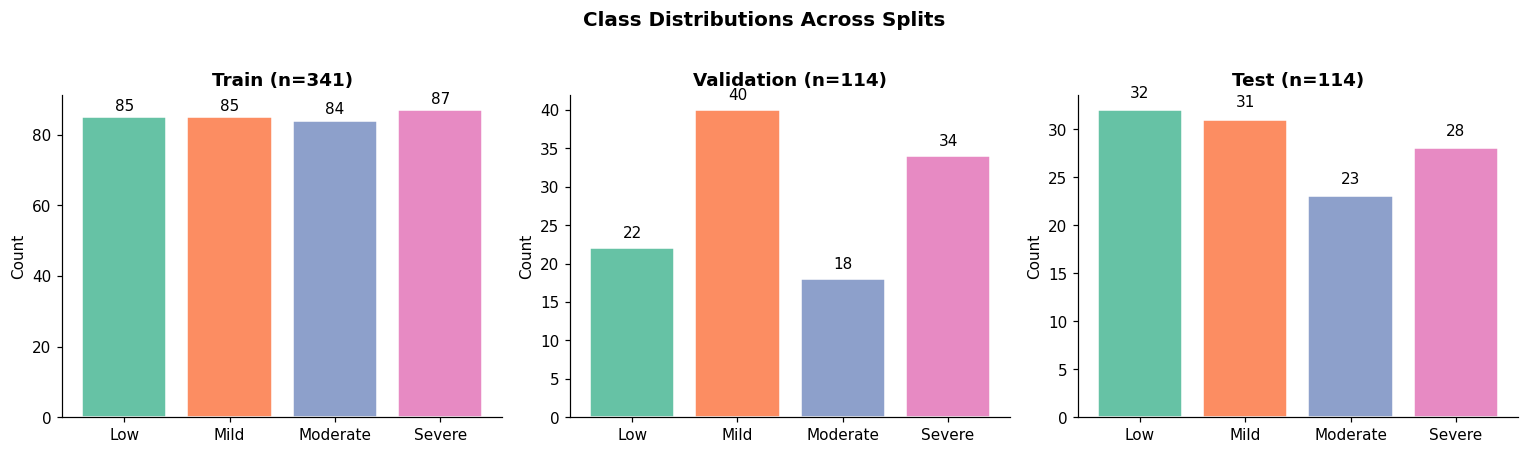

Note: Training set is roughly balanced (quartile-based binning ensures ~25% per class).
Val/test splits may differ since quartile boundaries were computed from training data only.


In [4]:
# ── Visualize class distributions ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, y_split, title in zip(axes, [y_train, y_val, y_test],
                               ['Train', 'Validation', 'Test']):
    counts = [np.sum(y_split == k) for k in range(K)]
    bars = ax.bar(class_names, counts, color=sns.color_palette('Set2', K), edgecolor='white')
    ax.set_title(f'{title} (n={len(y_split)})', fontweight='bold')
    ax.set_ylabel('Count')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(c), ha='center', va='bottom', fontsize=10)

fig.suptitle('Class Distributions Across Splits', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Note: Training set is roughly balanced (quartile-based binning ensures ~25% per class).")
print("Val/test splits may differ since quartile boundaries were computed from training data only.")

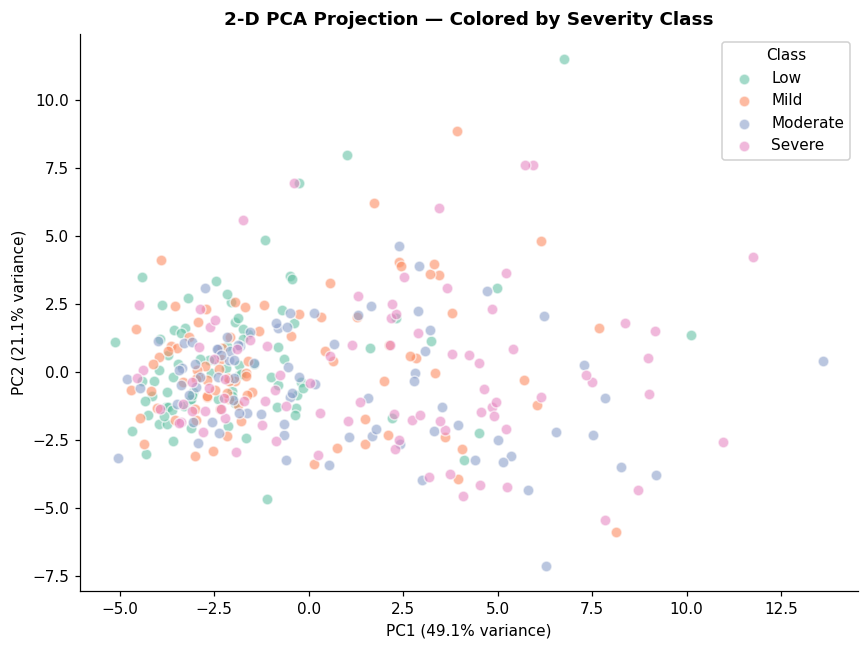

Notice how the 4 classes overlap substantially in PCA space.
This is expected — predicting texture severity from shape features is genuinely hard.
This makes the lab more realistic: perfect accuracy is NOT achievable.


In [5]:
# ── PCA projection to visualize class separability ────────────────────────────
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=42)
X_train_pca = pca_2d.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(8, 6))
colors = sns.color_palette('Set2', K)
for k in range(K):
    mask = y_train == k
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               c=[colors[k]], label=class_names[k], alpha=0.6, edgecolors='white', s=50)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('2-D PCA Projection — Colored by Severity Class', fontweight='bold')
ax.legend(title='Class', framealpha=0.9)
plt.tight_layout()
plt.show()

print("Notice how the 4 classes overlap substantially in PCA space.")
print("This is expected — predicting texture severity from shape features is genuinely hard.")
print("This makes the lab more realistic: perfect accuracy is NOT achievable.")

### 🤔 Reflection 1.1 — From Scalar to Vector Outputs

In Labs 1–5 the model output was a single probability $p \in [0,1]$. Now the model
must output a *vector* of probabilities $(p_1, p_2, p_3, p_4)$ that sum to 1.

1. Why can't we simply output 4 independent sigmoids — one per class? What mathematical
   constraint would be violated?

2. In binary classification, knowing $P(Y=1) = 0.7$ immediately tells you
   $P(Y=0) = 0.3$. With $K=4$ classes, how many *free* parameters does the model need
   to specify the full distribution? (Hint: it's not 4.)

3. Looking at the PCA plot above, do you expect this to be an easy or hard classification
   task? What does the overlap between classes suggest about the achievable accuracy?

---
## Part 2 — Softmax & Categorical Cross-Entropy from Scratch

In binary classification, the sigmoid function maps a single logit $z \in \mathbb{R}$
to a probability $p \in (0,1)$. For multi-class, we need a generalization that maps
a *vector* of logits $\mathbf{z} \in \mathbb{R}^K$ to a *probability distribution*
over $K$ classes.

**The softmax function:**
$$\text{softmax}(\mathbf{z})_k = \frac{\exp(z_k)}{\sum_{j=1}^{K} \exp(z_j)} \qquad k = 1, \ldots, K$$

Key properties:
- Every output is in $(0, 1)$
- Outputs sum to exactly 1
- Larger logits get larger probabilities (monotonic)
- When $K=2$, softmax reduces to sigmoid (verify this!)

**The categorical cross-entropy loss:**
$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} y_{ik} \log \hat{p}_{ik}$$

where $y_{ik}$ is the one-hot encoded label (1 if sample $i$ belongs to class $k$,
0 otherwise) and $\hat{p}_{ik} = \text{softmax}(\mathbf{z}_i)_k$.

In [6]:
def softmax_solution(z):
    """Numerically stable softmax."""
    z_stable = z - np.max(z, axis=-1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

# Verify
z_test = np.array([2.0, 1.0, 0.1, -1.0])
p = softmax_solution(z_test)
print(f"Softmax: {p}, sum: {p.sum():.6f}")

z_big = np.array([1000.0, 1001.0, 999.0, 998.0])
p_big = softmax_solution(z_big)
print(f"Large logits: {p_big}, any NaN: {np.any(np.isnan(p_big))}")

z_batch = np.array([[1, 2, 3, 4], [4, 3, 2, 1], [0, 0, 0, 0]], dtype=float)
p_batch = softmax_solution(z_batch)
print(f"Batch sums: {p_batch.sum(axis=1)}")
print(f"Uniform: {p_batch[2]}")


Softmax: [0.63806635 0.23473149 0.0954347  0.03176745], sum: 1.000000
Large logits: [0.23688282 0.64391426 0.08714432 0.0320586 ], any NaN: False
Batch sums: [1. 1. 1.]
Uniform: [0.25 0.25 0.25 0.25]


In [7]:
def categorical_cross_entropy_solution(y_onehot, p_hat, eps=1e-12):
    """Categorical cross-entropy loss."""
    p_clipped = np.clip(p_hat, eps, 1 - eps)
    loss = -np.mean(np.sum(y_onehot * np.log(p_clipped), axis=1))
    return loss

# Verify
y_oh = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1]])
p_perfect = np.array([[0.99, 0.003, 0.003, 0.004],
                       [0.01, 0.97, 0.01, 0.01],
                       [0.01, 0.01, 0.01, 0.97]])
p_uniform = np.full_like(y_oh, 0.25, dtype=float)

print(f"Near-perfect: {categorical_cross_entropy_solution(y_oh, p_perfect):.4f}")
print(f"Uniform:      {categorical_cross_entropy_solution(y_oh, p_uniform):.4f} (≈ log(4) = {np.log(4):.4f})")


Near-perfect: 0.0237
Uniform:      1.3863 (≈ log(4) = 1.3863)


In [8]:
# Solution: the key TODO lines in the training loop are:

# Forward pass
# z_train = X_train @ W + b
# p_train = softmax_solution(z_train)
# loss_t  = categorical_cross_entropy_solution(y_train_oh, p_train)

# Backward pass
# n = X_train.shape[0]
# dz = (1/n) * (p_train - y_train_oh)
# dW = X_train.T @ dz
# db = dz.sum(axis=0)

# Here's a complete runnable version:
def train_multiclass_solution(X_tr, y_tr_oh, X_vl, y_vl_oh, lr=0.5, n_epochs=500):
    np.random.seed(42)
    n_features = X_tr.shape[1]
    K = y_tr_oh.shape[1]
    W = np.random.randn(n_features, K) * 0.01
    b = np.zeros(K)
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        z_train = X_tr @ W + b
        p_train = softmax_solution(z_train)
        loss_t = categorical_cross_entropy_solution(y_tr_oh, p_train)

        n = X_tr.shape[0]
        dz = (1/n) * (p_train - y_tr_oh)
        dW = X_tr.T @ dz
        db = dz.sum(axis=0)

        W -= lr * dW
        b -= lr * db

        z_val_fwd = X_vl @ W + b
        p_val_fwd = softmax_solution(z_val_fwd)
        loss_v = categorical_cross_entropy_solution(y_vl_oh, p_val_fwd)
        train_losses.append(loss_t)
        val_losses.append(loss_v)

        if epoch % 100 == 0 or epoch == n_epochs - 1:
            acc_t = (p_train.argmax(axis=1) == y_tr_oh.argmax(axis=1)).mean()
            acc_v = (p_val_fwd.argmax(axis=1) == y_vl_oh.argmax(axis=1)).mean()
            print(f"Epoch {epoch:4d} | Train loss {loss_t:.4f} acc {acc_t:.3f} | Val loss {loss_v:.4f} acc {acc_v:.3f}")

    return W, b, train_losses, val_losses

print("Solution function defined. Call train_multiclass_solution(X_train, y_train_oh, X_val, y_val_oh) to run.")


Solution function defined. Call train_multiclass_solution(X_train, y_train_oh, X_val, y_val_oh) to run.


NameError: name 'train_losses' is not defined

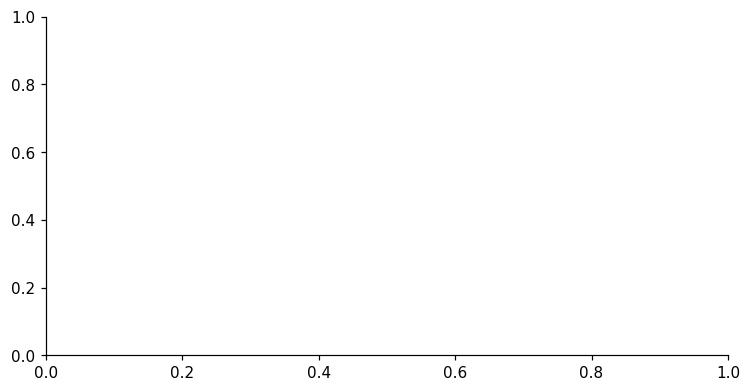

In [9]:
# ── Plot loss curves ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train', linewidth=2)
ax.plot(val_losses, label='Validation', linewidth=2, linestyle='--')
ax.axhline(np.log(K), color='gray', linestyle=':', alpha=0.5, label=f'Random guess (log {K} = {np.log(K):.2f})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Categorical Cross-Entropy Loss')
ax.set_title('Gradient Descent on a Linear Multi-Class Model', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 🤔 Reflection 2.1 — Connecting Binary and Multi-Class

1. **Algebraic verification:** Binary cross-entropy is $\mathcal{L} = -\frac{1}{n}\sum_i [y_i \log p_i + (1-y_i) \log(1-p_i)]$. Show that categorical cross-entropy with $K=2$ and one-hot labels $\mathbf{y} = (y, 1-y)$ reduces to exactly this expression.

2. **Gradient structure:** The gradient of binary cross-entropy w.r.t. the logit was $\hat{p} - y$ (from Lab 1). The gradient of categorical cross-entropy w.r.t. the logit vector is $\hat{\mathbf{p}} - \mathbf{y}$ — the same form! Why does this elegant structure arise? (Hint: it comes from the fact that softmax + cross-entropy form a natural pairing, analogous to sigmoid + binary cross-entropy.)

3. **Loss curve interpretation:** The horizontal line at $\log(4) \approx 1.386$ represents the loss of a model that always predicts uniform $\hat{p} = (0.25, 0.25, 0.25, 0.25)$. Your model's loss should be well below this. How far below? What does the gap between train and val loss tell you?

---
## Part 3 — One-vs-Rest (OvR) vs. Multinomial

There are two main strategies for extending binary classifiers to multi-class problems:

**One-vs-Rest (OvR):** Train $K$ independent binary classifiers. Classifier $k$ learns
to separate "class $k$" from "everything else." At prediction time, each classifier
outputs a score, and we pick the class with the highest score. The key issue: the $K$
sigmoid outputs are not coordinated — they don't know about each other and generally
don't sum to 1.

**Multinomial (softmax):** Train a single model with a $K$-way softmax output. The
model directly outputs a valid probability distribution. All classes compete in a
single, coordinated optimization.

In [10]:
from sklearn.linear_model import LogisticRegression

# ── Train both models ─────────────────────────────────────────────────────────
lr_ovr = LogisticRegression(multi_class='ovr', max_iter=2000, C=1.0, random_state=42)
lr_ovr.fit(X_train, y_train)

lr_multi = LogisticRegression(multi_class='multinomial', max_iter=2000, C=1.0,
                               solver='lbfgs', random_state=42)
lr_multi.fit(X_train, y_train)

print(f"OvR         — Train acc: {lr_ovr.score(X_train, y_train):.3f}, "
      f"Val acc: {lr_ovr.score(X_val, y_val):.3f}")
print(f"Multinomial — Train acc: {lr_multi.score(X_train, y_train):.3f}, "
      f"Val acc: {lr_multi.score(X_val, y_val):.3f}")
print(f"\nOvR weight matrix shape:         {lr_ovr.coef_.shape}  (K separate weight vectors)")
print(f"Multinomial weight matrix shape: {lr_multi.coef_.shape}  (same shape, jointly trained)")

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [11]:
# ── Compare predicted probability distributions on 5 example patients ─────────
np.random.seed(0)
sample_idx = np.random.choice(len(X_val), 5, replace=False)

p_ovr   = lr_ovr.predict_proba(X_val[sample_idx])
p_multi = lr_multi.predict_proba(X_val[sample_idx])

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5), sharey=True)
x_pos = np.arange(K)
width = 0.35

for i, (ax, idx) in enumerate(zip(axes, sample_idx)):
    ax.bar(x_pos - width/2, p_ovr[i],   width, label='OvR', alpha=0.8)
    ax.bar(x_pos + width/2, p_multi[i], width, label='Multinomial', alpha=0.8)
    true_k = y_val[idx]
    ax.set_title(f'Patient {idx}\nTrue: {class_names[true_k]}', fontsize=10)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['L', 'Mi', 'Mo', 'S'], fontsize=9)
    if i == 0:
        ax.set_ylabel('Predicted P')
        ax.legend(fontsize=8)

fig.suptitle('Predicted Probability Distributions: OvR vs. Multinomial',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

NameError: name 'lr_ovr' is not defined

In [12]:
# The key TODO lines:
# raw_logits_ovr = X_val[sample_idx] @ lr_ovr.coef_.T + lr_ovr.intercept_
# raw_sigmoid_ovr = sigmoid(raw_logits_ovr)
# normalized_ovr = raw_sigmoid_ovr / raw_sigmoid_ovr.sum(axis=1, keepdims=True)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

print("OvR solution: each binary classifier outputs an independent sigmoid.")
print("These don't sum to 1 because each classifier independently estimates P(class k vs. rest).")
print("Normalization divides by the sum to create a valid distribution, but this is ad hoc.")


OvR solution: each binary classifier outputs an independent sigmoid.
These don't sum to 1 because each classifier independently estimates P(class k vs. rest).
Normalization divides by the sum to create a valid distribution, but this is ad hoc.


### 🤔 Reflection 3.1 — OvR vs. Multinomial

1. You just showed that OvR's raw outputs don't form a valid probability distribution.
   In clinical decision support, a physician might use predicted probabilities directly
   (e.g., "this patient has a 60% chance of grade III"). When might the OvR normalization
   hack produce misleading probabilities?

2. Consider two very similar classes — say "mild" and "moderate" texture. The OvR
   classifier for "mild" treats "moderate" samples as negatives, even though they're
   the most confusable class. How might this hurt performance? Does the multinomial
   model handle this better?

3. OvR has a computational advantage: the $K$ binary classifiers can be trained in
   parallel, while multinomial requires joint optimization. When might this matter?

---
## Part 4 — Multi-Class Evaluation Metrics

Binary classification had sensitivity, specificity, PPV, NPV, and AUC. Multi-class
evaluation is richer and more nuanced — there's no single "sensitivity" anymore.
Instead, we have per-class metrics that must be aggregated.

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Confusion matrices for both models ────────────────────────────────────────
y_pred_ovr   = lr_ovr.predict(X_val)
y_pred_multi = lr_multi.predict(X_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes, [y_pred_ovr, y_pred_multi],
                              ['One-vs-Rest', 'Multinomial']):
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
    ax.set_title(f'{title}\nVal Accuracy: {(y_pred == y_val).mean():.3f}', fontweight='bold')

plt.tight_layout()
plt.show()

print("Read the confusion matrix: row = true class, column = predicted class.")
print("Diagonal entries are correct predictions. Off-diagonal are errors.")
print("Which pairs of classes are most frequently confused?")

NameError: name 'lr_ovr' is not defined

In [14]:
def compute_macro_f1_solution(y_true, y_pred, K):
    """Compute macro-averaged F1 score from scratch."""
    precisions, recalls, f1s = [], [], []

    for k in range(K):
        tp = np.sum((y_true == k) & (y_pred == k))
        fp = np.sum((y_true != k) & (y_pred == k))
        fn = np.sum((y_true == k) & (y_pred != k))

        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0

        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)

    macro_f1 = np.mean(f1s)
    return macro_f1, {'precision': precisions, 'recall': recalls, 'f1': f1s}

# Verify
from sklearn.metrics import f1_score
y_demo_true = np.array([0, 0, 1, 1, 2, 2, 3, 3])
y_demo_pred = np.array([0, 1, 1, 1, 2, 3, 3, 3])
f1_ours, _ = compute_macro_f1_solution(y_demo_true, y_demo_pred, 4)
f1_sk = f1_score(y_demo_true, y_demo_pred, average='macro')
print(f"Macro-F1 (ours):    {f1_ours:.4f}")
print(f"Macro-F1 (sklearn): {f1_sk:.4f}")
print(f"Match: {np.isclose(f1_ours, f1_sk)}")


Macro-F1 (ours):    0.7333
Macro-F1 (sklearn): 0.7333
Match: True


In [15]:
# ── Micro-F1 and Weighted-F1 ─────────────────────────────────────────────────
micro_f1    = f1_score(y_val, y_pred_multi, average='micro')
weighted_f1 = f1_score(y_val, y_pred_multi, average='weighted')

print("F1 Score Variants (Multinomial model):")
print("─" * 45)
print(f"  Macro-F1:    {macro_f1_ours:.4f}   (unweighted mean of per-class F1)")
print(f"  Micro-F1:    {micro_f1:.4f}   (global TP, FP, FN → single F1)")
print(f"  Weighted-F1: {weighted_f1:.4f}   (per-class F1 weighted by support)")
print()
print("Key differences:")
print("  • Macro:    treats all classes equally — poor performance on ANY class hurts")
print("  • Micro:    dominated by the most common class")
print("  • Weighted: each class contributes proportionally to its prevalence")
print()
print("Full classification report:")
print(classification_report(y_val, y_pred_multi, target_names=class_names, digits=3))

NameError: name 'y_pred_multi' is not defined

In [16]:
# ── Multi-class AUROC ─────────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_val_bin = label_binarize(y_val, classes=list(range(K)))
p_multi_val = lr_multi.predict_proba(X_val)
p_ovr_val   = lr_ovr.predict_proba(X_val)

# OvR AUC: compute per-class AUC (each class vs. rest), then average
auc_ovr_multi = roc_auc_score(y_val_bin, p_multi_val, multi_class='ovr', average='macro')
auc_ovo_multi = roc_auc_score(y_val_bin, p_multi_val, multi_class='ovo', average='macro')

auc_ovr_ovr = roc_auc_score(y_val_bin, p_ovr_val, multi_class='ovr', average='macro')
auc_ovo_ovr = roc_auc_score(y_val_bin, p_ovr_val, multi_class='ovo', average='macro')

print("Multi-class AUROC:")
print("─" * 55)
print(f"{'':15s} {'OvR AUC':>12s} {'OvO AUC':>12s}")
print(f"{'OvR model':15s} {auc_ovr_ovr:12.4f} {auc_ovo_ovr:12.4f}")
print(f"{'Multinomial':15s} {auc_ovr_multi:12.4f} {auc_ovo_multi:12.4f}")
print()
print("OvR AUC: average of K one-vs-rest ROC curves")
print("OvO AUC: average of K(K-1)/2 one-vs-one ROC curves")
print(f"\nFor K={K} classes, OvO averages over {K*(K-1)//2} pairwise comparisons.")

NameError: name 'lr_multi' is not defined

### 🤔 Reflection 4.1 — Choosing the Right Metric

1. Look at the per-class metrics above. Which classes have the lowest F1? Why might
   adjacent classes (e.g., "mild" and "moderate") be harder to distinguish than
   distant ones ("low" and "severe")?

2. Macro-F1 weighs all classes equally, so poor performance on any single class drags
   the overall metric down. Weighted-F1 weights by class prevalence. In a clinical
   grading system (e.g., cancer grade I–IV), which weighting scheme is more appropriate?
   Does the answer depend on whether the classes are ordinal?

3. The multi-class AUROC is an aggregate measure. When might you want to report the
   *per-class* AUC instead? Think of a clinical scenario where one class matters
   much more than the others.

---
## Part 5 — Ordinal Structure: What Cross-Entropy Ignores

Standard categorical cross-entropy treats all misclassifications equally:
predicting "low" when the truth is "severe" incurs the **same loss** as predicting
"moderate." For ordinal targets, this is clinically wrong — one error is mild,
the other is catastrophic.

This section explores what happens when we respect (or ignore) the ordinal structure.

In [17]:
# ── Distance-weighted confusion matrix ───────────────────────────────────────
# Standard confusion matrix counts errors. A distance-weighted version weights
# each error by |true_class - predicted_class|, penalizing far-off predictions.

def distance_weighted_confusion(y_true, y_pred, K):
    """Compute confusion matrix weighted by ordinal distance |i - j|."""
    cm = confusion_matrix(y_true, y_pred, labels=list(range(K)))
    weights = np.abs(np.arange(K)[:, None] - np.arange(K)[None, :])
    return cm, weights, cm * weights

cm_multi, dist_weights, dwcm_multi = distance_weighted_confusion(y_val, y_pred_multi, K)
cm_ovr, _, dwcm_ovr = distance_weighted_confusion(y_val, y_pred_ovr, K)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Distance weight matrix
sns.heatmap(dist_weights, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Distance Weights |i − j|', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# Distance-weighted confusion: OvR
sns.heatmap(dwcm_ovr, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title(f'OvR — Weighted Error: {dwcm_ovr.sum()}', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

# Distance-weighted confusion: Multinomial
sns.heatmap(dwcm_multi, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=class_names, yticklabels=class_names)
axes[2].set_title(f'Multinomial — Weighted Error: {dwcm_multi.sum()}', fontweight='bold')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

plt.tight_layout()
plt.show()

# Mean absolute ordinal error
mae_ovr   = np.mean(np.abs(y_val - y_pred_ovr))
mae_multi = np.mean(np.abs(y_val - y_pred_multi))
print(f"Mean Absolute Ordinal Error — OvR: {mae_ovr:.3f}, Multinomial: {mae_multi:.3f}")
print("(Lower is better — this measures how many 'grades' off the prediction is, on average)")

NameError: name 'y_pred_multi' is not defined

In [18]:
# ── Ordinal Regression via Cumulative Binary Classifiers ──────────────────────
# Approach: fit K-1 = 3 binary classifiers predicting P(Y > k) for k = 0, 1, 2.
# Then: P(Y = 0) = 1 - P(Y > 0)
#       P(Y = k) = P(Y > k-1) - P(Y > k)   for k = 1, ..., K-2
#       P(Y = K-1) = P(Y > K-2)

# Fit cumulative binary classifiers
ordinal_models = []
for k in range(K - 1):
    y_binary = (y_train > k).astype(int)
    model_k = LogisticRegression(max_iter=2000, C=1.0, random_state=42)
    model_k.fit(X_train, y_binary)
    ordinal_models.append(model_k)
    acc_k = model_k.score(X_val, (y_val > k).astype(int))
    print(f"P(Y > {k}) classifier — Val accuracy: {acc_k:.3f}")

# Predict cumulative probabilities
cum_probs = np.column_stack([
    model.predict_proba(X_val)[:, 1] for model in ordinal_models
])

# Enforce monotonicity: P(Y > 0) >= P(Y > 1) >= P(Y > 2)
# Use isotonic regression (simple clip approach)
for i in range(cum_probs.shape[0]):
    for j in range(1, cum_probs.shape[1]):
        cum_probs[i, j] = min(cum_probs[i, j], cum_probs[i, j-1])

# Convert cumulative to class probabilities
p_ordinal = np.zeros((len(X_val), K))
p_ordinal[:, 0] = 1.0 - cum_probs[:, 0]              # P(Y = 0) = 1 - P(Y > 0)
for k in range(1, K - 1):
    p_ordinal[:, k] = cum_probs[:, k-1] - cum_probs[:, k]  # P(Y = k) = P(Y > k-1) - P(Y > k)
p_ordinal[:, K-1] = cum_probs[:, -1]                  # P(Y = K-1) = P(Y > K-2)

# Clip any numerical issues
p_ordinal = np.clip(p_ordinal, 0, 1)
p_ordinal = p_ordinal / p_ordinal.sum(axis=1, keepdims=True)

y_pred_ordinal = p_ordinal.argmax(axis=1)

# Compare all three models
mae_ordinal = np.mean(np.abs(y_val - y_pred_ordinal))
acc_ordinal = (y_pred_ordinal == y_val).mean()

_, _, dwcm_ordinal = distance_weighted_confusion(y_val, y_pred_ordinal, K)

print(f"\n{'Model':15s} {'Accuracy':>10s} {'MAE (ord.)':>12s} {'Weighted Error':>15s}")
print("─" * 55)
print(f"{'OvR':15s} {(y_pred_ovr==y_val).mean():10.3f} {mae_ovr:12.3f} {dwcm_ovr.sum():15d}")
print(f"{'Multinomial':15s} {(y_pred_multi==y_val).mean():10.3f} {mae_multi:12.3f} {dwcm_multi.sum():15d}")
print(f"{'Ordinal':15s} {acc_ordinal:10.3f} {mae_ordinal:12.3f} {dwcm_ordinal.sum():15d}")

P(Y > 0) classifier — Val accuracy: 0.816
P(Y > 1) classifier — Val accuracy: 0.702
P(Y > 2) classifier — Val accuracy: 0.702

Model             Accuracy   MAE (ord.)  Weighted Error
───────────────────────────────────────────────────────


NameError: name 'y_pred_ovr' is not defined

### 🤔 Reflection 5.1 — Ordinal Awareness

1. Ordinal regression constrains predictions so that $P(Y > 1) \geq P(Y > 2) \geq P(Y > 3)$.
   Why is this a natural constraint for an ordinal target? What would it mean if this
   constraint were violated?

2. Compare the distance-weighted error across the three models. Does ordinal regression
   reduce the severity of misclassifications (i.e., errors are closer to the true class),
   even if overall accuracy is similar?

3. Can you think of a clinical multi-class problem where ordinal regression would be
   **inappropriate**? (Hint: consider cancer subtypes like luminal A, luminal B, HER2+,
   triple-negative — these differ in *kind*, not *degree*.)

---
## Part 6 — Class Imbalance in Multi-Class Settings

In the real world, clinical grading systems are almost never balanced. The most severe
categories are typically the rarest — but also the most clinically important. Here we
artificially create imbalance to study its effects and remedies.

In [19]:
# ── Create artificial class imbalance ─────────────────────────────────────────
# Downsample the "severe" class to ~10% of its original size in the training set.

np.random.seed(42)
severe_mask = y_train == 3
severe_idx  = np.where(severe_mask)[0]
n_keep = max(int(len(severe_idx) * 0.10), 3)  # keep ~10%, at least 3
keep_severe = np.random.choice(severe_idx, n_keep, replace=False)

# Combine: all non-severe + downsampled severe
other_idx = np.where(~severe_mask)[0]
imb_idx = np.concatenate([other_idx, keep_severe])
np.random.shuffle(imb_idx)

X_train_imb = X_train[imb_idx]
y_train_imb = y_train[imb_idx]

print("Original training class distribution:")
for k in range(K):
    print(f"  {class_names[k]:10s}: {(y_train == k).sum():4d}")
print(f"\nImbalanced training class distribution (severe downsampled to ~10%):")
for k in range(K):
    count = (y_train_imb == k).sum()
    print(f"  {class_names[k]:10s}: {count:4d}  {'⚠️ rare!' if k == 3 else ''}")

Original training class distribution:
  Low       :   85
  Mild      :   85
  Moderate  :   84
  Severe    :   87

Imbalanced training class distribution (severe downsampled to ~10%):
  Low       :   85  
  Mild      :   85  
  Moderate  :   84  
  Severe    :    8  ⚠️ rare!


In [20]:
# ── Train on imbalanced data: baseline (no correction) ───────────────────────
lr_imb_base = LogisticRegression(multi_class='multinomial', max_iter=2000,
                                  solver='lbfgs', random_state=42)
lr_imb_base.fit(X_train_imb, y_train_imb)
y_pred_imb_base = lr_imb_base.predict(X_val)

print("Baseline model (no imbalance correction):")
print(classification_report(y_val, y_pred_imb_base, target_names=class_names, digits=3))

print("\n⚠️ Look at the recall for 'Severe' — the model almost never predicts it!")
print(f"   Severe recall: {(y_pred_imb_base[y_val == 3] == 3).mean():.3f}")
print(f"   Overall accuracy: {(y_pred_imb_base == y_val).mean():.3f}")
print("   → High accuracy masks the failure on the clinically important class.")

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [21]:
# ── Remedy 1: Class-weighted cross-entropy ───────────────────────────────────
lr_imb_weighted = LogisticRegression(multi_class='multinomial', max_iter=2000,
                                      solver='lbfgs', random_state=42,
                                      class_weight='balanced')
lr_imb_weighted.fit(X_train_imb, y_train_imb)
y_pred_imb_weighted = lr_imb_weighted.predict(X_val)

print("Class-weighted model (class_weight='balanced'):")
print(classification_report(y_val, y_pred_imb_weighted, target_names=class_names, digits=3))

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [22]:
# ── Remedy 2: Oversampling with SMOTE ────────────────────────────────────────
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', '-q', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imb, y_train_imb)

print("After SMOTE oversampling:")
for k in range(K):
    print(f"  {class_names[k]:10s}: {(y_train_smote == k).sum():4d}")

lr_imb_smote = LogisticRegression(multi_class='multinomial', max_iter=2000,
                                   solver='lbfgs', random_state=42)
lr_imb_smote.fit(X_train_smote, y_train_smote)
y_pred_imb_smote = lr_imb_smote.predict(X_val)

print("\nSMOTE model:")
print(classification_report(y_val, y_pred_imb_smote, target_names=class_names, digits=3))

After SMOTE oversampling:
  Low       :   85
  Mild      :   85
  Moderate  :   85
  Severe    :   85


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

NameError: name 'y_pred_imb_base' is not defined

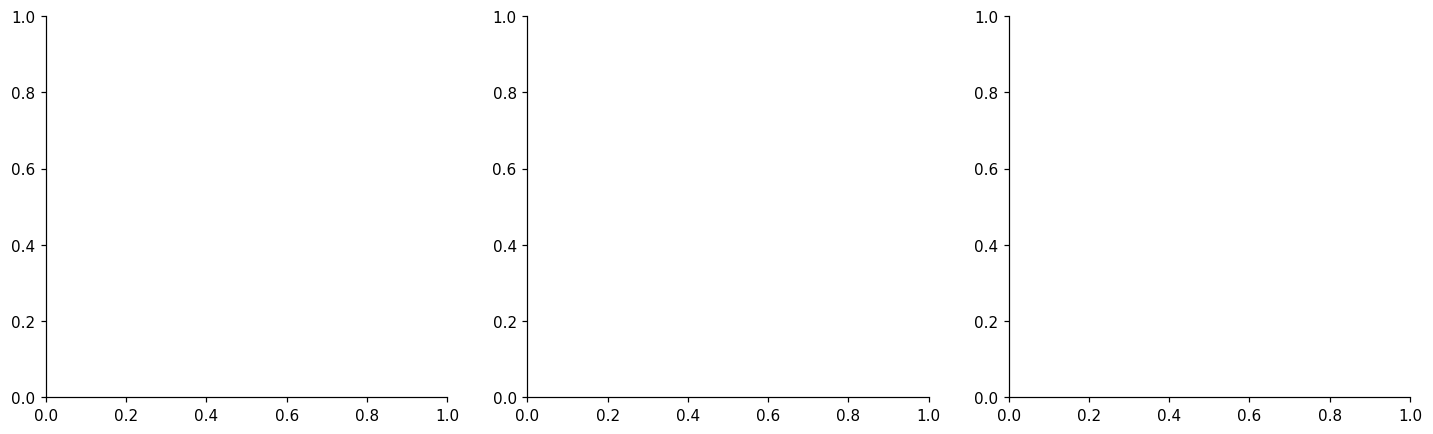

In [23]:
# ── Compare all three approaches ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, y_pred, title in zip(axes,
    [y_pred_imb_base, y_pred_imb_weighted, y_pred_imb_smote],
    ['Baseline (no correction)', 'Class-weighted', 'SMOTE oversampling']):

    cm = confusion_matrix(y_val, y_pred, labels=list(range(K)))
    # Normalize by row (true class) to show recall per class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                vmin=0, vmax=1)
    acc = (y_pred == y_val).mean()
    macro = f1_score(y_val, y_pred, average='macro')
    ax.set_title(f'{title}\nAcc={acc:.3f}, Macro-F1={macro:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

fig.suptitle('Row-Normalized Confusion Matrices (Per-Class Recall)',
             fontweight='bold', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

print("Each cell shows P(predicted class | true class) = recall for that class.")
print("The diagonal shows per-class recall — the metric we care most about.")

### 🤔 Reflection 6.1 — Imbalance and Clinical Reporting

1. The baseline model achieves decent overall accuracy by rarely predicting "severe."
   In a tumor grading system, the "severe" category is rarest but most clinically
   important. A model that achieves 92% overall accuracy by mostly ignoring the severe
   class is clinically **dangerous**. How should you report performance to a clinical
   audience to make this failure visible?

2. Class weighting and SMOTE both aim to improve recall on the minority class. What
   are the tradeoffs? (Hint: look at what happens to precision and recall of the
   *majority* classes.)

3. SMOTE generates synthetic samples by interpolating between existing minority-class
   samples. Why might this be problematic for medical data? (Consider: does interpolating
   between two real patients always produce a realistic synthetic patient?)

---
## Part 7 — Final Test Set Evaluation

Following the same protocol as Labs 1–5: we evaluate on the test set **once**, using
the model and configuration chosen on the validation set.

In [24]:
# ── Final evaluation on test set ─────────────────────────────────────────────
# Use the multinomial model trained on the FULL (balanced) training set
y_pred_test  = lr_multi.predict(X_test)
p_test_proba = lr_multi.predict_proba(X_test)
y_test_bin   = label_binarize(y_test, classes=list(range(K)))

print("═" * 60)
print("  FINAL TEST SET EVALUATION — Multinomial Logistic Regression")
print("═" * 60)
print(classification_report(y_test, y_pred_test, target_names=class_names, digits=3))

# Multi-class AUC
test_auc_ovr = roc_auc_score(y_test_bin, p_test_proba, multi_class='ovr', average='macro')
test_auc_ovo = roc_auc_score(y_test_bin, p_test_proba, multi_class='ovo', average='macro')
print(f"  Multi-class AUROC (OvR): {test_auc_ovr:.4f}")
print(f"  Multi-class AUROC (OvO): {test_auc_ovo:.4f}")

# Ordinal-aware metric
mae_test = np.mean(np.abs(y_test - y_pred_test))
print(f"  Mean Absolute Ordinal Error: {mae_test:.3f}")
print("═" * 60)

NameError: name 'lr_multi' is not defined

NameError: name 'y_pred_test' is not defined

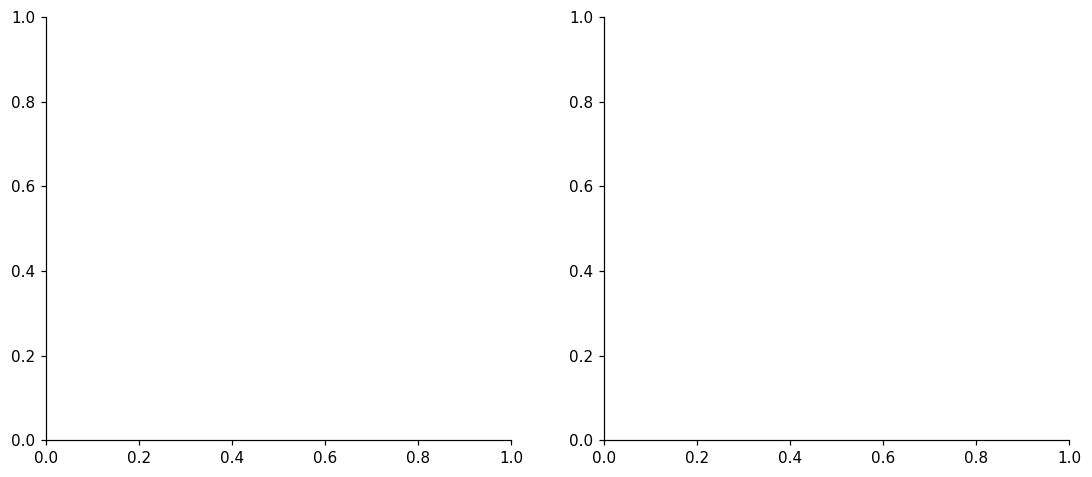

In [25]:
# ── Test set confusion matrix ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw counts
cm_test = confusion_matrix(y_test, y_pred_test, labels=list(range(K)))
disp = ConfusionMatrixDisplay(cm_test, display_labels=class_names)
disp.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Test Set — Counts', fontweight='bold')

# Distance-weighted
_, dw, dwcm_test = distance_weighted_confusion(y_test, y_pred_test, K)
sns.heatmap(dwcm_test, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title(f'Test Set — Distance-Weighted Errors (total: {dwcm_test.sum()})',
                   fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

---
## 🤔 Final Reflection

You're building a model to classify chest X-rays into 5 severity categories:
**normal, mild, moderate, severe, critical.** Answer the following:

1. **Loss function:** Which loss would you use — standard categorical cross-entropy
   or an ordinal-aware loss? What's the clinical argument for each? Is predicting
   "normal" when the truth is "critical" really the same as predicting "severe"?

2. **Class imbalance:** "Normal" is 10× more common than "critical." Based on what
   you observed in Part 6, what would happen to a model trained without any
   imbalance correction? Which remedy would you try first, and why?

3. **Evaluation metrics:** You're presenting results to the clinical team. You can
   show them *two* metrics. Which two do you choose, and why? Consider:
   - Overall accuracy vs. macro-F1 vs. weighted-F1
   - Standard confusion matrix vs. distance-weighted confusion matrix
   - Per-class recall (especially for "critical")
   - Multi-class AUROC

4. **Model output:** A physician asks, "What does the model think about this patient?"
   Would you show them the predicted class label, or the full probability distribution
   over all 5 categories? What additional information does the distribution provide?